<a href="https://colab.research.google.com/github/sakshi-nandgude/Big-Data-Loan-Default-Prediction/blob/main/Big_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
from pyspark.sql import SparkSession
!pip install openpyxl -q
import pandas as pd
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, IntegerType

Connect with Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

spark = SparkSession.builder \
    .appName("BigDataProject") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)
print("Spark is ready!")

file_path = "/content/drive/MyDrive/final_big_data_loan_dataset.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
print("Rows    :", df.count())
print("Columns :", len(df.columns))

Mounted at /content/drive
Spark version: 4.0.2
Spark is ready!
Rows    : 1048575
Columns : 151


List files in your Drive

In [ ]:
for root, dirs, files in os.walk('/content/drive/MyDrive/Big_Data'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Big_Data/final_big_data_loan_dataset.csv
/content/drive/MyDrive/Big_Data/cleaned_big_data_loan_dataset.csv
/content/drive/MyDrive/Big_Data/cleaned_big_data_loan_file.csv/part-00000-b0b696d8-71dd-46a1-a1f3-c1f36d3cbbf7-c000.csv


Load dataset into spark

In [ ]:
df.show(3)

+--------+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+------------+----------+--------------+----------+-------------------+-------+-----------+----------+--------------------+----+------------------+------------------+--------+----------+-----+-----------+----------------+--------------+---------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+----------------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------+-------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-------+------

Drop unecessary columns

In [ ]:
cols_to_drop = [
    # Identifiers
    "id", "member_id", "url", "desc", "title",

    # Post-loan outcome (data leakage)
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee", "last_pymnt_d",
    "last_pymnt_amnt", "next_pymnt_d",

    # Redundant columns
    "funded_amnt_inv", "funded_amnt", "sub_grade",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low",

    # Hardship columns (95% null)
    "hardship_flag", "hardship_type", "hardship_reason",
    "hardship_status", "deferral_term", "hardship_amount",
    "hardship_start_date", "hardship_end_date",
    "payment_plan_start_date", "hardship_length", "hardship_dpd",
    "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",

    # Settlement columns (95% null)
    "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term",

    # Joint app columns (mostly null)
    "annual_inc_joint", "dti_joint", "verification_status_joint",
    "revol_bal_joint", "sec_app_fico_range_low",
    "sec_app_fico_range_high", "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths", "sec_app_mort_acc",
    "sec_app_open_acc", "sec_app_revol_util",
    "sec_app_open_act_il", "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog",

    # Other low-value columns
    "zip_code", "addr_state", "issue_d", "earliest_cr_line",
    "initial_list_status", "pymnt_plan", "policy_code",
    "application_type", "disbursement_method"
]

# Only drop columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df = df.drop(*cols_to_drop)

print("Columns remaining:", len(df.columns))
print("Columns:", df.columns)

Columns remaining: 81
Columns: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since

Filter loan_status to Fully Paid and Charged Off only

In [ ]:
df = df.filter(df["loan_status"].isin(["Fully Paid", "Charged Off"]))
print("Rows after filtering:", df.count())
df.groupBy("loan_status").count().show()

Rows after filtering: 611781
+-----------+------+
|loan_status| count|
+-----------+------+
| Fully Paid|482595|
|Charged Off|129186|
+-----------+------+



Remove duplicates


In [ ]:
before = df.count()
df = df.dropDuplicates()
after  = df.count()
print(f"Removed {before - after} duplicates")
print(f"Final rows: {after}")

Removed 0 duplicates
Final rows: 611781


check for null values


In [ ]:
# Count nulls per column
null_counts = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).toPandas().T.rename(columns={0: "null_count"})

# Show only columns that have nulls
null_counts = null_counts[null_counts["null_count"] > 0] \
              .sort_values("null_count", ascending=False)

print("=== COLUMNS WITH NULL VALUES ===")
print(f"Total columns with nulls: {len(null_counts)}")
print()
print(null_counts.to_string())

# Show as percentage too
print("\n=== NULL PERCENTAGE ===")
total = df.count()
null_counts["null_%"] = (null_counts["null_count"] / total * 100).round(2)
print(null_counts.to_string())

=== COLUMNS WITH NULL VALUES ===
Total columns with nulls: 40

                                null_count
mths_since_last_record              498818
mths_since_recent_bc_dlq            457763
mths_since_last_major_derog         434949
mths_since_recent_revol_delinq      394946
il_util                             391389
mths_since_rcnt_il                  363497
all_util                            356622
open_il_24m                         356599
total_cu_tl                         356599
open_rv_24m                         356599
max_bal_bc                          356599
total_bal_il                        356599
inq_fi                              356599
inq_last_12m                        356599
open_act_il                         356599
open_il_12m                         356599
open_rv_12m                         356599
open_acc_6m                         356599
mths_since_last_delinq              298467
mths_since_recent_inq                60141
emp_title                         

Drop columns with many null values

In [ ]:
high_null_cols = [
    # 81% null
    "mths_since_last_record",
    # 74% null
    "mths_since_recent_bc_dlq",
    # 71% null
    "mths_since_last_major_derog",
    # 64% null
    "mths_since_recent_revol_delinq",
    # 63% null
    "il_util",
    # 59% null
    "mths_since_rcnt_il",
    # 58% null — all same group
    "all_util", "open_il_24m", "total_cu_tl",
    "open_rv_24m", "max_bal_bc", "total_bal_il",
    "inq_fi", "inq_last_12m", "open_act_il",
    "open_il_12m", "open_rv_12m", "open_acc_6m",
    # 48% null
    "mths_since_last_delinq"
]

df = df.drop(*high_null_cols)
print("Columns after dropping high null cols:", len(df.columns))

Columns after dropping high null cols: 62


Fill remaining null values

In [ ]:
df = df.fillna({
    # 9.8% null — no recent inquiry = 0
    "mths_since_recent_inq" : 0.0,
    # 4.6% null — no delinquency = 0
    "num_tl_120dpd_2m"      : 0.0,
    # 2.8% null — no instalment account = 0
    "mo_sin_old_il_acct"    : 0.0,
    # 1.1% null — no utilisation = 0
    "bc_util"               : 0.0,
    # 1.1% null — no cards over 75% = 0
    "percent_bc_gt_75"      : 0.0,
    # 1.0% null — no open credit = 0
    "bc_open_to_buy"        : 0.0,
    # 1.0% null — no recent bank card = 0
    "mths_since_recent_bc"  : 0.0,
    # 0.05% null — tiny, fill zero
    "revol_util"            : 0.0,
    # 0.04% null — tiny, fill zero
    "dti"                   : 0.0,
    # 0.00% null — tiny, fill zero
    "avg_cur_bal"           : 0.0,

    # Text columns — fill with Unknown
    "emp_title"             : "Unknown",
    "emp_length"            : "Unknown"
})

print("Nulls filled!")

Nulls filled!


Drop remaining null rows


In [ ]:
before = df.count()
df = df.dropna()
after = df.count()
print(f"Dropped {before - after} rows")
print(f"Rows remaining: {after}")

Dropped 3 rows
Rows remaining: 611778


Verify zero null values remaining

In [ ]:
remaining = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).toPandas().T.rename(columns={0: "null_count"})

remaining = remaining[remaining["null_count"] > 0]

if len(remaining) == 0:
    print("No nulls remaining!")
else:
    print("Still has nulls:")
    print(remaining)

print("\nFinal rows    :", df.count())
print("Final columns :", len(df.columns))
print("\nClass balance:")
df.groupBy("loan_status") \
  .count() \
  .withColumn("pct",
    (col("count") / df.count() * 100).cast("decimal(5,2)")) \
  .show()

No nulls remaining!

Final rows    : 611778
Final columns : 62

Class balance:
+-----------+------+-----+
|loan_status| count|  pct|
+-----------+------+-----+
| Fully Paid|482593|78.88|
|Charged Off|129185|21.12|
+-----------+------+-----+



Clean term column (remove " months", convert to integer)

In [ ]:
from pyspark.sql.functions import regexp_replace, trim, col

df = df.withColumn("term",
    regexp_replace(trim(col("term")), " months", "").cast("integer"))

print("Term column cleaned:")
df.select("term").distinct().show()

Term column cleaned:
+----+
|term|
+----+
|  60|
|  36|
+----+



Clean emp_length column (convert to number)

In [ ]:
from pyspark.sql.functions import when

df = df.withColumn("emp_length",
    when(col("emp_length") == "< 1 year", 0)
    .when(col("emp_length") == "1 year",   1)
    .when(col("emp_length") == "2 years",  2)
    .when(col("emp_length") == "3 years",  3)
    .when(col("emp_length") == "4 years",  4)
    .when(col("emp_length") == "5 years",  5)
    .when(col("emp_length") == "6 years",  6)
    .when(col("emp_length") == "7 years",  7)
    .when(col("emp_length") == "8 years",  8)
    .when(col("emp_length") == "9 years",  9)
    .when(col("emp_length") == "10+ years",10)
    .otherwise(0)
    .cast("integer"))

print("emp_length column cleaned:")
df.select("emp_length").distinct().orderBy("emp_length").show()

emp_length column cleaned:
+----------+
|emp_length|
+----------+
|         0|
|         1|
|         2|
|         3|
|         4|
|         5|
|         6|
|         7|
|         8|
|         9|
|        10|
+----------+



Encode loan_status to 0 and 1

In [ ]:
df = df.withColumn("loan_status",
    when(col("loan_status") == "Fully Paid",  0)
    .when(col("loan_status") == "Charged Off", 1)
    .cast("integer"))

print("loan_status encoded:")
df.groupBy("loan_status").count().show()

loan_status encoded:
+-----------+------+
|loan_status| count|
+-----------+------+
|          1|129185|
|          0|482593|
+-----------+------+



Verify and fix data types

In [ ]:
# Ensure these are all correct numeric types
num_cols = [
    "loan_amnt", "int_rate", "installment", "annual_inc",
    "dti", "delinq_2yrs", "fico_range_low", "fico_range_high",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "acc_now_delinq", "tot_coll_amt",
    "tot_cur_bal", "total_rev_hi_lim", "acc_open_past_24mths",
    "avg_cur_bal", "bc_open_to_buy", "bc_util",
    "chargeoff_within_12_mths", "delinq_amnt",
    "mo_sin_old_il_acct", "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl", "mort_acc",
    "mths_since_recent_bc", "mths_since_recent_inq",
    "num_accts_ever_120_pd", "num_actv_bc_tl", "num_actv_rev_tl",
    "num_bc_sats", "num_bc_tl", "num_il_tl", "num_op_rev_tl",
    "num_rev_accts", "num_rev_tl_bal_gt_0", "num_sats",
    "num_tl_120dpd_2m", "num_tl_30dpd", "num_tl_90g_dpd_24m",
    "num_tl_op_past_12m", "pct_tl_nvr_dlq", "percent_bc_gt_75",
    "pub_rec_bankruptcies", "tax_liens", "tot_hi_cred_lim",
    "total_bal_ex_mort", "total_bc_limit",
    "total_il_high_credit_limit", "collections_12_mths_ex_med"
]

for c in num_cols:
    if c in df.columns:
        df = df.withColumn(c, col(c).cast(DoubleType()))

print("Data types fixed!")
df.printSchema()

Data types fixed!
root
 |-- loan_amnt: double (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- emp_title: string (nullable = false)
 |-- emp_length: integer (nullable = false)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- loan_status: integer (nullable = true)
 |-- purpose: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- inq_last_6mths: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: double (nullable = false)
 |-- total_acc: double (nullable = true)
 |-- collections_12_mths_ex_med: double (nullable 

Final Check

In [ ]:
print("="*45)
print("FINAL CLEANED DATASET")
print("="*45)
print("Rows    :", df.count())
print("Columns :", len(df.columns))

print("\nClass balance:")
df.groupBy("loan_status") \
  .count() \
  .withColumn("pct",
    (col("count") / df.count() * 100).cast("decimal(5,2)")) \
  .show()

print("\nSample:")
df.show(3)

FINAL CLEANED DATASET
Rows    : 611778
Columns : 62

Class balance:
+-----------+------+-----+
|loan_status| count|  pct|
+-----------+------+-----+
|          1|129185|21.12|
|          0|482593|78.88|
+-----------+------+-----+


Sample:
+---------+----+--------+-----------+-----+--------------------+----------+--------------+----------+-------------------+-----------+------------------+-----+-----------+--------------+---------------+--------------+--------+-------+---------+----------+---------+--------------------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------

In [ ]:
save_path = "/content/drive/MyDrive/Big_Data/cleaned_big_data_loan_file.csv"
df.coalesce(1).write.csv(save_path, header=True, mode="overwrite")

print("Saved successfully!")
print("Rows:", df.count())
print("Cols:", len(df.columns))

Saved successfully!
Rows: 611778
Cols: 62


Data Quality Check

In [ ]:
from pyspark.sql.functions import col

print("=== GRADE VALUES ===")
df.groupBy("grade").count() \
  .orderBy("count", ascending=False).show()

print("=== HOME OWNERSHIP VALUES ===")
df.groupBy("home_ownership").count() \
  .orderBy("count", ascending=False).show()

print("=== PURPOSE VALUES ===")
df.groupBy("purpose").count() \
  .orderBy("count", ascending=False).show()

print("=== VERIFICATION STATUS VALUES ===")
df.groupBy("verification_status").count() \
  .orderBy("count", ascending=False).show()

print("=== CLASS BALANCE ===")
total = df.count()
df.groupBy("loan_status") \
  .count() \
  .withColumn("pct",
    (col("count") / total * 100).cast("decimal(5,2)")) \
  .show()

print("=== ZERO VARIANCE CHECK ===")
for c in ["loan_amnt", "int_rate", "annual_inc",
          "dti", "revol_util", "fico_range_low"]:
    distinct = df.select(c).distinct().count()
    print(f"{c}: {distinct} distinct values")

=== GRADE VALUES ===
+-----+------+
|grade| count|
+-----+------+
|    C|174802|
|    B|173212|
|    A|117025|
|    D| 86040|
|    E| 42915|
|    F| 13437|
|    G|  4347|
+-----+------+

=== HOME OWNERSHIP VALUES ===
+--------------+------+
|home_ownership| count|
+--------------+------+
|      MORTGAGE|298505|
|          RENT|243393|
|           OWN| 69863|
|           ANY|    15|
|          NONE|     2|
+--------------+------+

=== PURPOSE VALUES ===
+------------------+------+
|           purpose| count|
+------------------+------+
|debt_consolidation|354475|
|       credit_card|136929|
|  home_improvement| 41683|
|             other| 34948|
|    major_purchase| 12961|
|           medical|  7088|
|               car|  6033|
|    small_business|  5605|
|          vacation|  4386|
|            moving|  4341|
|             house|  2958|
|  renewable_energy|   364|
|           wedding|     6|
|       educational|     1|
+------------------+------+

=== VERIFICATION STATUS VALUES ===
+--

Schema overview

In [ ]:
df.printSchema()

root
 |-- loan_amnt: double (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- emp_title: string (nullable = false)
 |-- emp_length: integer (nullable = false)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- loan_status: integer (nullable = true)
 |-- purpose: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- inq_last_6mths: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: double (nullable = false)
 |-- total_acc: double (nullable = true)
 |-- collections_12_mths_ex_med: double (nullable = true)
 |-- acc_n

Summary Statistics

In [ ]:
df.describe().show()


+-------+------------------+------------------+-----------------+------------------+------+--------------------+-----------------+--------------+-----------------+-------------------+-------------------+-------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+------------------+--------------------------+--------------------+------------------+------------------+-----------------+--------------------+------------------+------------------+-----------------+------------------------+------------------+------------------+--------------------+---------------------+-----------------+------------------+--------------------+---------------------+---------------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+-------------------+------------------+--------------------+--------------------

EDA Setup

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import os

# colours for the charts - blue and red theme
BLUE       = '#2471A3'
RED        = '#C0392B'
BAR_COLORS = [BLUE, RED]

# global chart settings
plt.rcParams['figure.figsize']   = (8, 5)
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

SAVE_DIR = '/content/'

# save and show the chart
def save_show(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"saved → {SAVE_DIR}{filename}")

# register as sql table so we can query it
df.createOrReplaceTempView("loans")
print("set, done")

set, done


In [ ]:
# get a summary of the dataset
spark.sql("""
    SELECT
        COUNT(*)                                     AS total_loans,
        ROUND(AVG(loan_amnt), 2)                     AS avg_loan_amount,
        ROUND(AVG(int_rate), 2)                      AS avg_interest_rate,
        ROUND(AVG(annual_inc), 2)                    AS avg_annual_income,
        ROUND(AVG(dti), 2)                                            AS avg_dti,
        SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)               AS total_defaults,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2)                                       AS default_rate_pct
    FROM loans
""").show()

+-----------+---------------+-----------------+-----------------+-------+--------------+----------------+
|total_loans|avg_loan_amount|avg_interest_rate|avg_annual_income|avg_dti|total_defaults|default_rate_pct|
+-----------+---------------+-----------------+-----------------+-------+--------------+----------------+
|     611778|       14558.66|            12.72|         76875.33|  18.95|        129185|           21.12|
+-----------+---------------+-----------------+-----------------+-------+--------------+----------------+



In [ ]:
# checking for missing values
spark.sql("""
    SELECT
        SUM(CASE WHEN loan_amnt      IS NULL THEN 1 ELSE 0 END) AS loan_amnt_nulls,
        SUM(CASE WHEN int_rate       IS NULL THEN 1 ELSE 0 END) AS int_rate_nulls,
        SUM(CASE WHEN annual_inc     IS NULL THEN 1 ELSE 0 END) AS annual_inc_nulls,
        SUM(CASE WHEN dti            IS NULL THEN 1 ELSE 0 END) AS dti_nulls,
        SUM(CASE WHEN fico_range_low IS NULL THEN 1 ELSE 0 END) AS fico_nulls,
        SUM(CASE WHEN grade          IS NULL THEN 1 ELSE 0 END) AS grade_nulls,
        SUM(CASE WHEN home_ownership IS NULL THEN 1 ELSE 0 END) AS home_nulls,
        SUM(CASE WHEN purpose        IS NULL THEN 1 ELSE 0 END) AS purpose_nulls,
        SUM(CASE WHEN loan_status    IS NULL THEN 1 ELSE 0 END) AS target_nulls,
        SUM(CASE WHEN emp_length     IS NULL THEN 1 ELSE 0 END) AS emp_length_nulls
    FROM loans
""").show()

print('no missing values found')

+---------------+--------------+----------------+---------+----------+-----------+----------+-------------+------------+----------------+
|loan_amnt_nulls|int_rate_nulls|annual_inc_nulls|dti_nulls|fico_nulls|grade_nulls|home_nulls|purpose_nulls|target_nulls|emp_length_nulls|
+---------------+--------------+----------------+---------+----------+-----------+----------+-------------+------------+----------------+
|              0|             0|               0|        0|         0|          0|         0|            0|           0|               0|
+---------------+--------------+----------------+---------+----------+-----------+----------+-------------+------------+----------------+

no missing values found


Visual 1:- Loan Default Distribution

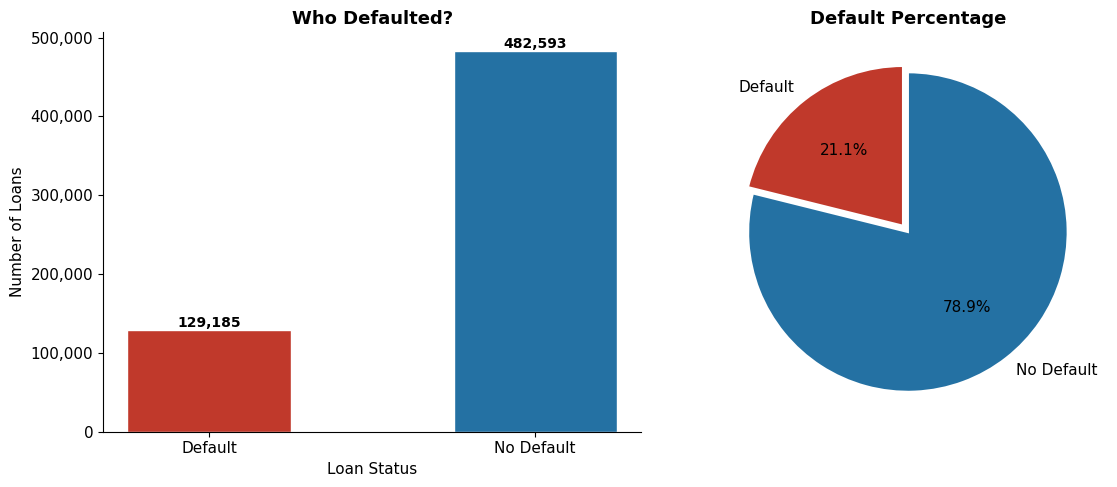

saved → /content/chart1_who_defaulted.png
       status   count    pct
0     Default  129185  21.12
1  No Default  482593  78.88


In [ ]:
# pull default  from sql
status = spark.sql("""
    SELECT
        CASE WHEN loan_status = 1 THEN 'Default' ELSE 'No Default' END AS status,
        COUNT(*) AS count,
        ROUND(COUNT(*) / 611778.0 * 100, 2) AS pct
    FROM loans
    GROUP BY loan_status
""").toPandas()

# make sure Default comes first so red lands on it
status = status.sort_values('status', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# red = default, blue = no default
colours = [RED, BLUE]

# bar chart - count
bars = axes[0].bar(status['status'], status['count'],
                   color=colours, edgecolor='white', width=0.5)
axes[0].set_title('Who Defaulted?')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Number of Loans')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, status['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 4000,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# pie chart - percentage breakdown
axes[1].pie(
    status['count'],
    labels=status['status'],
    autopct='%1.1f%%',
    colors=colours,
    startangle=90,
    explode=(0.05, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Default Percentage')

save_show('chart1_who_defaulted.png')
print(status)

Visual 2 — Loan Amount Distribution & Amount Impact on Default

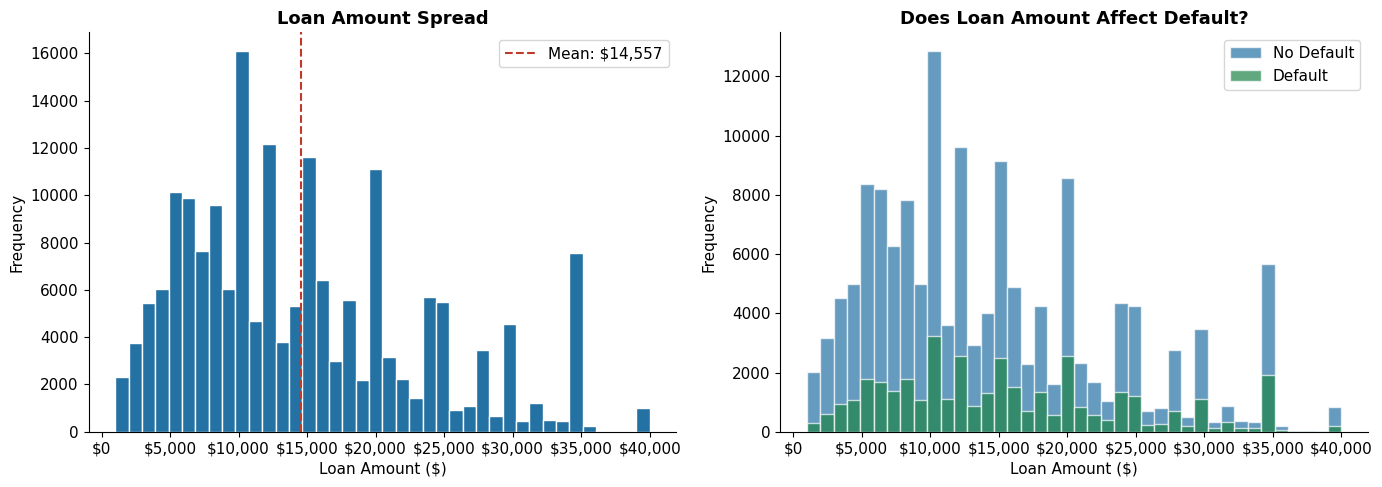

saved → /content/chart2_loan_amounts.png


In [ ]:
# sample data
loan_pd = df.select('loan_amnt', 'loan_status').sample(fraction=0.3).toPandas()
loan_pd['loan_status'] = loan_pd['loan_status'].astype(str)

# colours for this chart
GREEN = '#1E8449'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall loan amount spread
axes[0].hist(loan_pd['loan_amnt'], bins=40, color=BLUE, edgecolor='white')
axes[0].set_title('Loan Amount Spread')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
mean_val = loan_pd['loan_amnt'].mean()
axes[0].axvline(mean_val, color=RED, linestyle='--',
                linewidth=1.5, label=f'Mean: ${mean_val:,.0f}')
axes[0].legend()

# does loan amount affect who defaults?
axes[1].hist(loan_pd[loan_pd['loan_status']=='0']['loan_amnt'],
             bins=40, alpha=0.7, color=BLUE, edgecolor='white', label='No Default')
axes[1].hist(loan_pd[loan_pd['loan_status']=='1']['loan_amnt'],
             bins=40, alpha=0.7, color=GREEN, edgecolor='white', label='Default')
axes[1].set_title('Does Loan Amount Affect Default?')
axes[1].set_xlabel('Loan Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

save_show('chart2_loan_amounts.png')

Visual 3 - Grade vs Interest Rate and Default

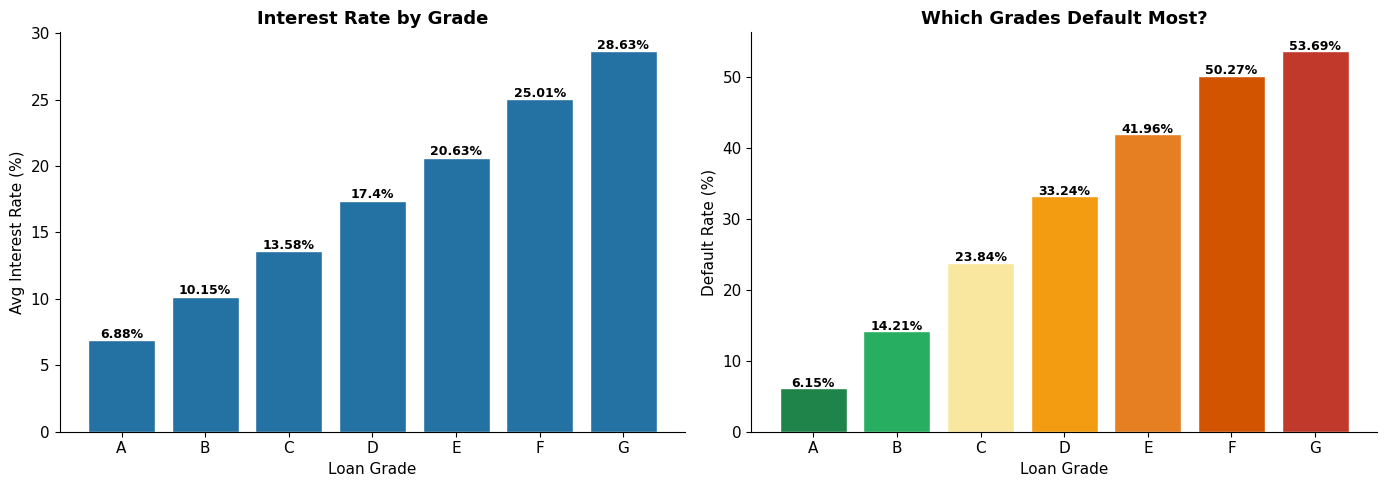

saved → /content/chart3_grade_analysis.png
  grade  avg_int_rate  default_rate   count
0     A          6.88          6.15  117025
1     B         10.15         14.21  173212
2     C         13.58         23.84  174802
3     D         17.40         33.24   86040
4     E         20.63         41.96   42915
5     F         25.01         50.27   13437
6     G         28.63         53.69    4347


In [ ]:
# grade stats from sql
grade_stats = spark.sql("""
    SELECT
        grade,
        ROUND(AVG(int_rate), 2)                                            AS avg_int_rate,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2)                                          AS default_rate,
        COUNT(*)                                                            AS count
    FROM loans
    GROUP BY grade
    ORDER BY grade
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left chart - interest rate per grade (blue)
bars1 = axes[0].bar(grade_stats['grade'], grade_stats['avg_int_rate'],
                    color=BLUE, edgecolor='white')
axes[0].set_title('Interest Rate by Grade')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Avg Interest Rate (%)')
for bar, val in zip(bars1, grade_stats['avg_int_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val}%', ha='center', fontsize=9, fontweight='bold')

# right chart - colour shifts green to orange as default risk increases A to G
grade_colours = ['#1E8449', '#27AE60', '#F9E79F', '#F39C12', '#E67E22', '#D35400', '#C0392B']
bars2 = axes[1].bar(grade_stats['grade'], grade_stats['default_rate'],
                    color=grade_colours, edgecolor='white')
axes[1].set_title('Which Grades Default Most?')
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('Default Rate (%)')
for bar, val in zip(bars2, grade_stats['default_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val}%', ha='center', fontsize=9, fontweight='bold')

save_show('chart3_grade_analysis.png')
print(grade_stats)

Visual 4 — Loan Purpose & Default Risk

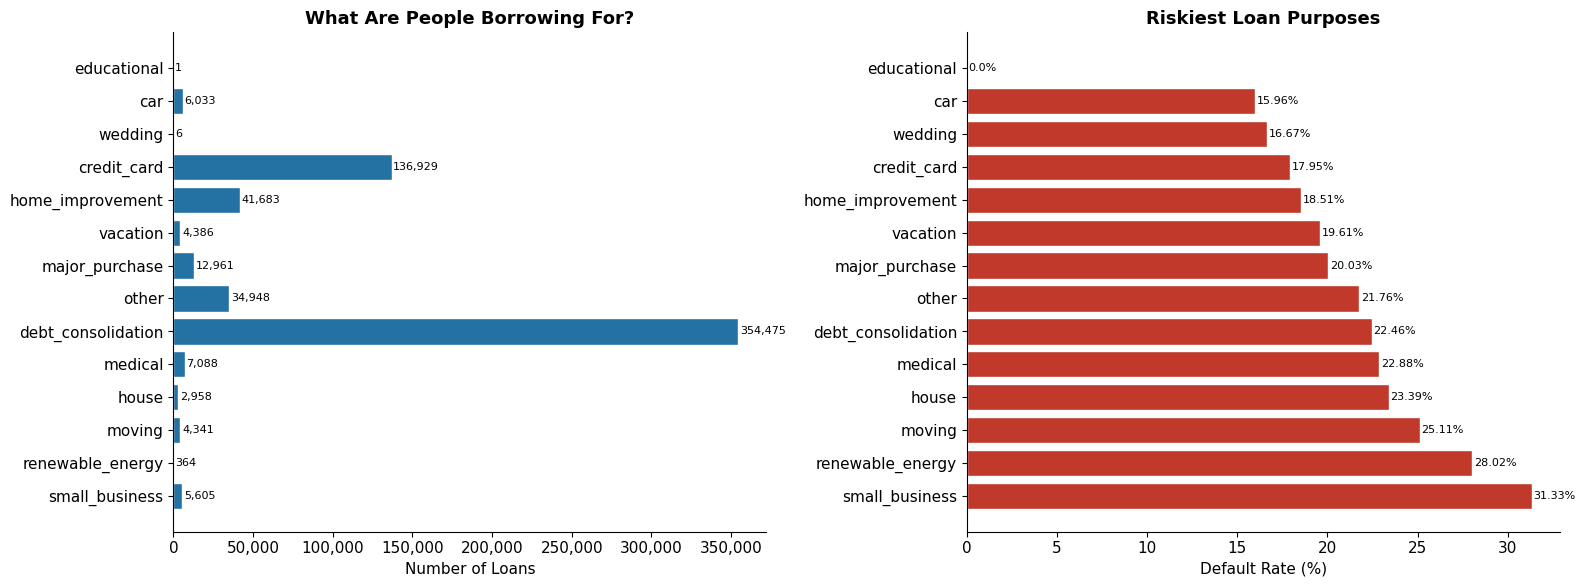

saved → /content/chart4_loan_purposes.png
               purpose   count  default_rate
0       small_business    5605         31.33
1     renewable_energy     364         28.02
2               moving    4341         25.11
3                house    2958         23.39
4              medical    7088         22.88
5   debt_consolidation  354475         22.46
6                other   34948         21.76
7       major_purchase   12961         20.03
8             vacation    4386         19.61
9     home_improvement   41683         18.51
10         credit_card  136929         17.95
11             wedding       6         16.67
12                 car    6033         15.96
13         educational       1          0.00


In [ ]:
# default rate by loan purpose
purpose_stats = spark.sql("""
    SELECT
        purpose,
        COUNT(*) AS count,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2) AS default_rate
    FROM loans
    GROUP BY purpose
    ORDER BY default_rate DESC
""").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left chart - volume per purpose
bars1 = axes[0].barh(purpose_stats['purpose'], purpose_stats['count'],
                     color=BLUE, edgecolor='white')
axes[0].set_title('What Are People Borrowing For?')
axes[0].set_xlabel('Number of Loans')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars1, purpose_stats['count']):
    axes[0].text(bar.get_width() + 1000,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# right chart - which purposes default the most
bars2 = axes[1].barh(purpose_stats['purpose'], purpose_stats['default_rate'],
                     color=RED, edgecolor='white')
axes[1].set_title('Riskiest Loan Purposes')
axes[1].set_xlabel('Default Rate (%)')
for bar, val in zip(bars2, purpose_stats['default_rate']):
    axes[1].text(bar.get_width() + 0.1,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=8)

save_show('chart4_loan_purposes.png')
print(purpose_stats)

Visual 5 — FICO Score & Default

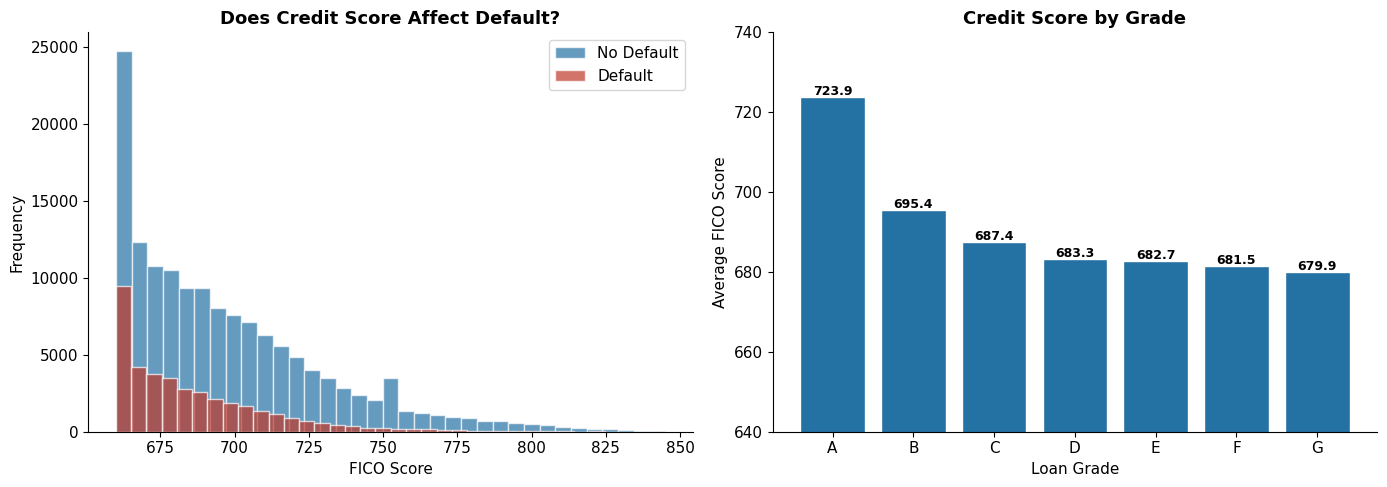

saved → /content/chart5_fico_scores.png


In [ ]:
# sample fico data
fico_pd = df.select('fico_range_low', 'loan_status').sample(fraction=0.3).toPandas()
fico_pd['loan_status'] = fico_pd['loan_status'].astype(str)
# avg fico per grade from sql
fico_grade = spark.sql("""
    SELECT grade,
        ROUND(AVG(fico_range_low), 1) AS avg_fico
    FROM loans
    GROUP BY grade
    ORDER BY grade
""").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# left chart - does credit score affect who defaults?
axes[0].hist(fico_pd[fico_pd['loan_status']=='0']['fico_range_low'],
             bins=35, alpha=0.7, color=BLUE, edgecolor='white', label='No Default')
axes[0].hist(fico_pd[fico_pd['loan_status']=='1']['fico_range_low'],
             bins=35, alpha=0.7, color=RED, edgecolor='white', label='Default')
axes[0].set_title('Does Credit Score Affect Default?')
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
# right chart - avg fico per grade
bars = axes[1].bar(fico_grade['grade'], fico_grade['avg_fico'],
                   color=BLUE, edgecolor='white')
axes[1].set_title('Credit Score by Grade')
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('Average FICO Score')
axes[1].set_ylim(640, 740)
for bar, val in zip(bars, fico_grade['avg_fico']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=9, fontweight='bold')
save_show('chart5_fico_scores.png')

Visual 6 — DTI & Employment vs Default

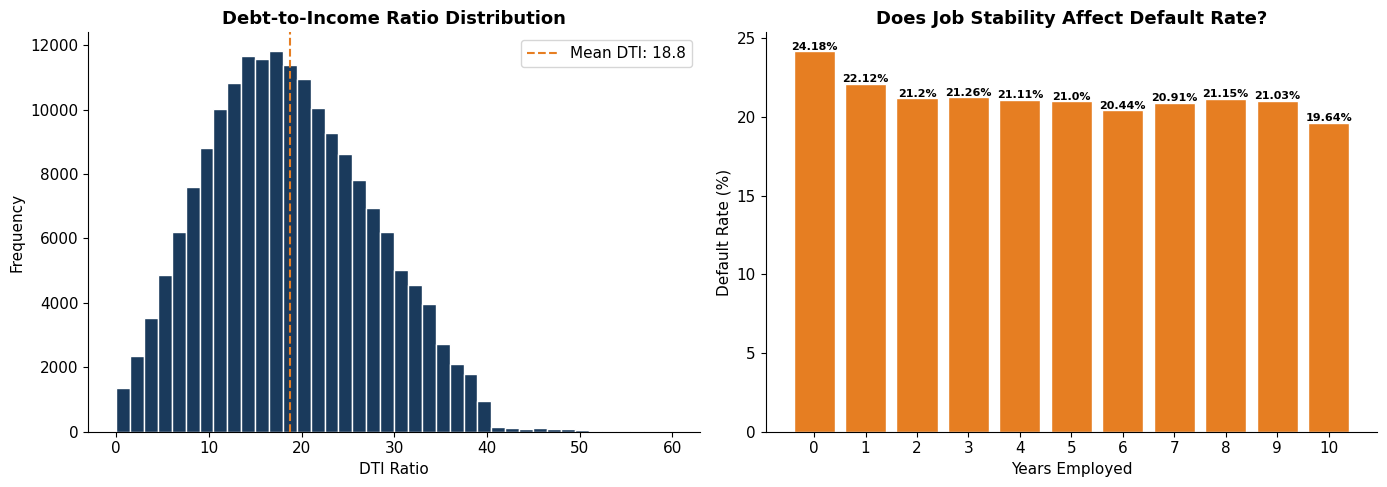

saved → /content/chart6_dti_employment.png


In [ ]:
# new colours for this chart
ORANGE = '#E67E22'
NAVY = '#1A3A5C'
# sample dti data and filter out outliers
dti_pd = df.select('dti').filter(col('dti').between(0, 60)).sample(fraction=0.3).toPandas()
# default rate by employment length from sql
emp_stats = spark.sql("""
    SELECT
        emp_length,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2) AS default_rate,
        COUNT(*) AS count
    FROM loans
    GROUP BY emp_length
    ORDER BY emp_length
""").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# left chart - dti distribution
axes[0].hist(dti_pd['dti'], bins=40, color=NAVY, edgecolor='white')
axes[0].set_title('Debt-to-Income Ratio Distribution')
axes[0].set_xlabel('DTI Ratio')
axes[0].set_ylabel('Frequency')
mean_dti = dti_pd['dti'].mean()
axes[0].axvline(mean_dti, color=ORANGE, linestyle='--',
                linewidth=1.5, label=f'Mean DTI: {mean_dti:.1f}')
axes[0].legend()
# right chart - does employment length affect default rate?
bars = axes[1].bar(emp_stats['emp_length'].astype(str),
                   emp_stats['default_rate'],
                   color=ORANGE, edgecolor='white')
axes[1].set_title('Does Job Stability Affect Default Rate?')
axes[1].set_xlabel('Years Employed')
axes[1].set_ylabel('Default Rate (%)')
for bar, val in zip(bars, emp_stats['default_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val}%', ha='center', fontsize=8, fontweight='bold')
save_show('chart6_dti_employment.png')

Visual 8 — Loan Term Analysis

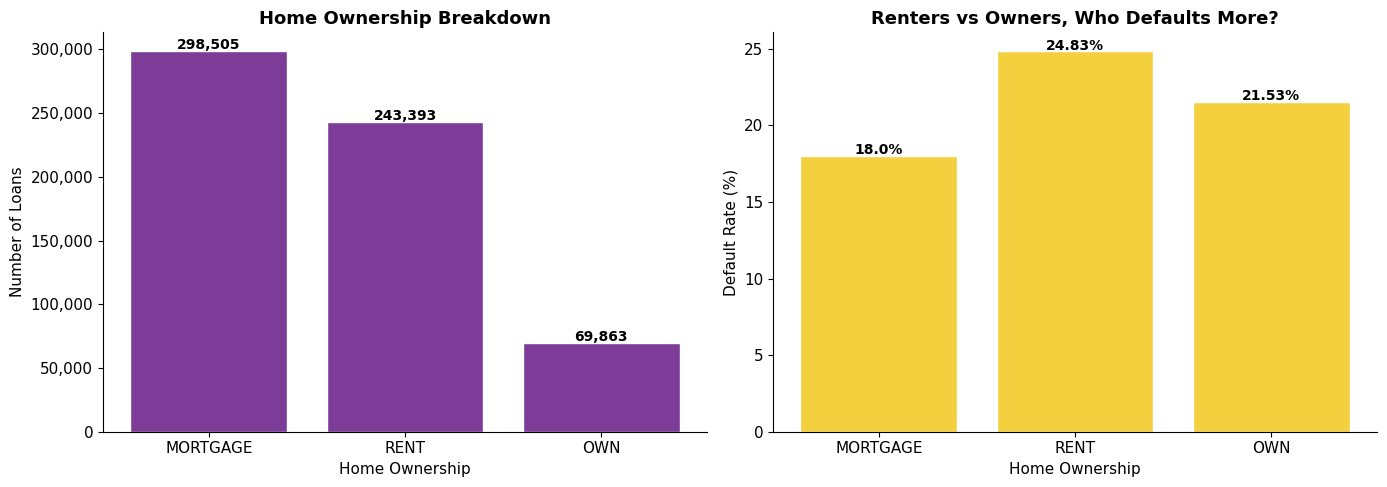

saved → /content/chart7_home_ownership.png
  home_ownership   count  default_rate
0       MORTGAGE  298505         18.00
1           RENT  243393         24.83
2            OWN   69863         21.53


In [ ]:
# colours for this chart
PURPLE = '#7D3C98'
YELLOW = '#F4D03F'
# pull home ownership stats from sql - filter out tiny categories
home_stats = spark.sql("""
    SELECT
        home_ownership,
        COUNT(*) AS count,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2) AS default_rate
    FROM loans
    WHERE home_ownership IN ('MORTGAGE', 'RENT', 'OWN')
    GROUP BY home_ownership
    ORDER BY count DESC
""").toPandas()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# left chart - how many loans per ownership type
bars1 = axes[0].bar(home_stats['home_ownership'], home_stats['count'],
                    color=PURPLE, edgecolor='white')
axes[0].set_title('Home Ownership Breakdown')
axes[0].set_xlabel('Home Ownership')
axes[0].set_ylabel('Number of Loans')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars1, home_stats['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1500,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
# right chart - renters vs owners, who defaults more?
bars2 = axes[1].bar(home_stats['home_ownership'], home_stats['default_rate'],
                    color=YELLOW, edgecolor='white')
axes[1].set_title('Renters vs Owners, Who Defaults More?')
axes[1].set_xlabel('Home Ownership')
axes[1].set_ylabel('Default Rate (%)')
for bar, val in zip(bars2, home_stats['default_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val}%', ha='center', fontweight='bold', fontsize=10)
save_show('chart7_home_ownership.png')
print(home_stats)

Visual 8 — Loan Term Analysis

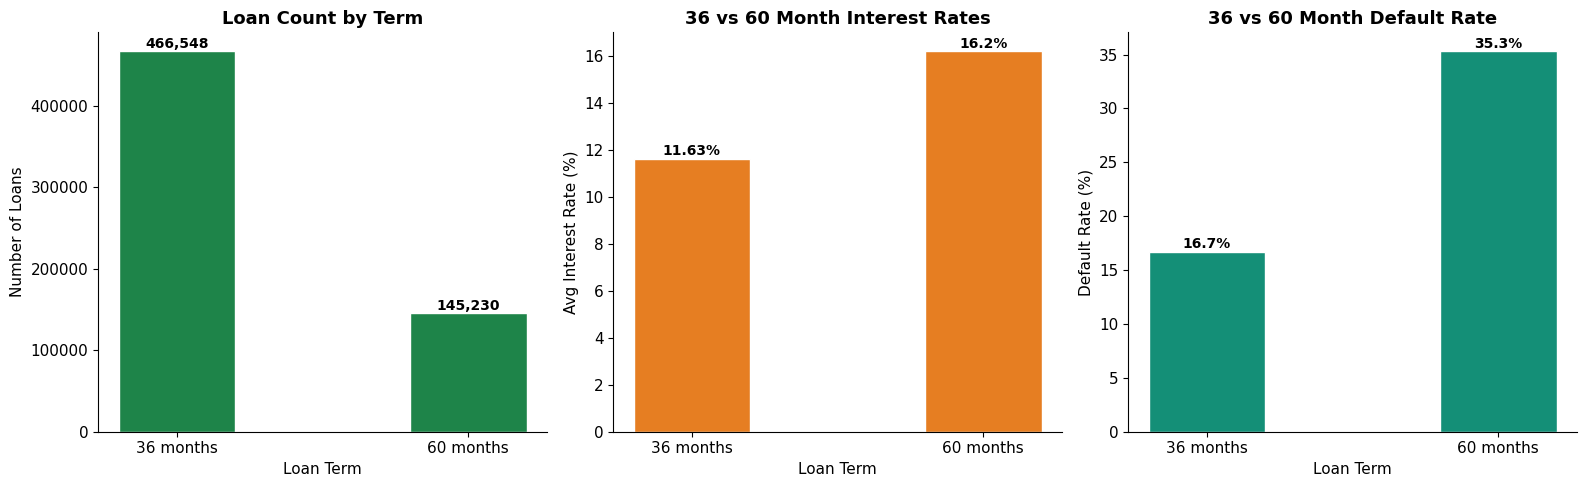

saved → /content/chart8_loan_terms.png
   term   count  avg_int_rate  default_rate
0    36  466548         11.63          16.7
1    60  145230         16.20          35.3


In [ ]:
GREEN = '#1E8449'
TEAL = '#148F77'
ORANGE = '#E67E22'
term_stats = spark.sql("""
    SELECT
        term,
        COUNT(*) AS count,
        ROUND(AVG(int_rate), 2) AS avg_int_rate,
        ROUND(SUM(CASE WHEN loan_status = 1 THEN 1 ELSE 0 END)
              / COUNT(*) * 100, 2) AS default_rate
    FROM loans
    GROUP BY term
    ORDER BY term
""").toPandas()
term_labels = term_stats['term'].astype(str) + ' months'
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, ylabel, title, color in zip(
    axes,
    ['count', 'avg_int_rate', 'default_rate'],
    ['Number of Loans', 'Avg Interest Rate (%)', 'Default Rate (%)'],
    ['Loan Count by Term', '36 vs 60 Month Interest Rates', '36 vs 60 Month Default Rate'],
    [GREEN, ORANGE, TEAL]
):
    bars = ax.bar(term_labels, term_stats[metric],
                  color=color, edgecolor='white', width=0.4)
    ax.set_title(title)
    ax.set_xlabel('Loan Term')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, term_stats[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(term_stats[metric]) * 0.01,
                f'{val:,}' if metric == 'count' else f'{val}%',
                ha='center', fontweight='bold', fontsize=10)
save_show('chart8_loan_terms.png')
print(term_stats)

Visual 9 — Correlation Heatmap



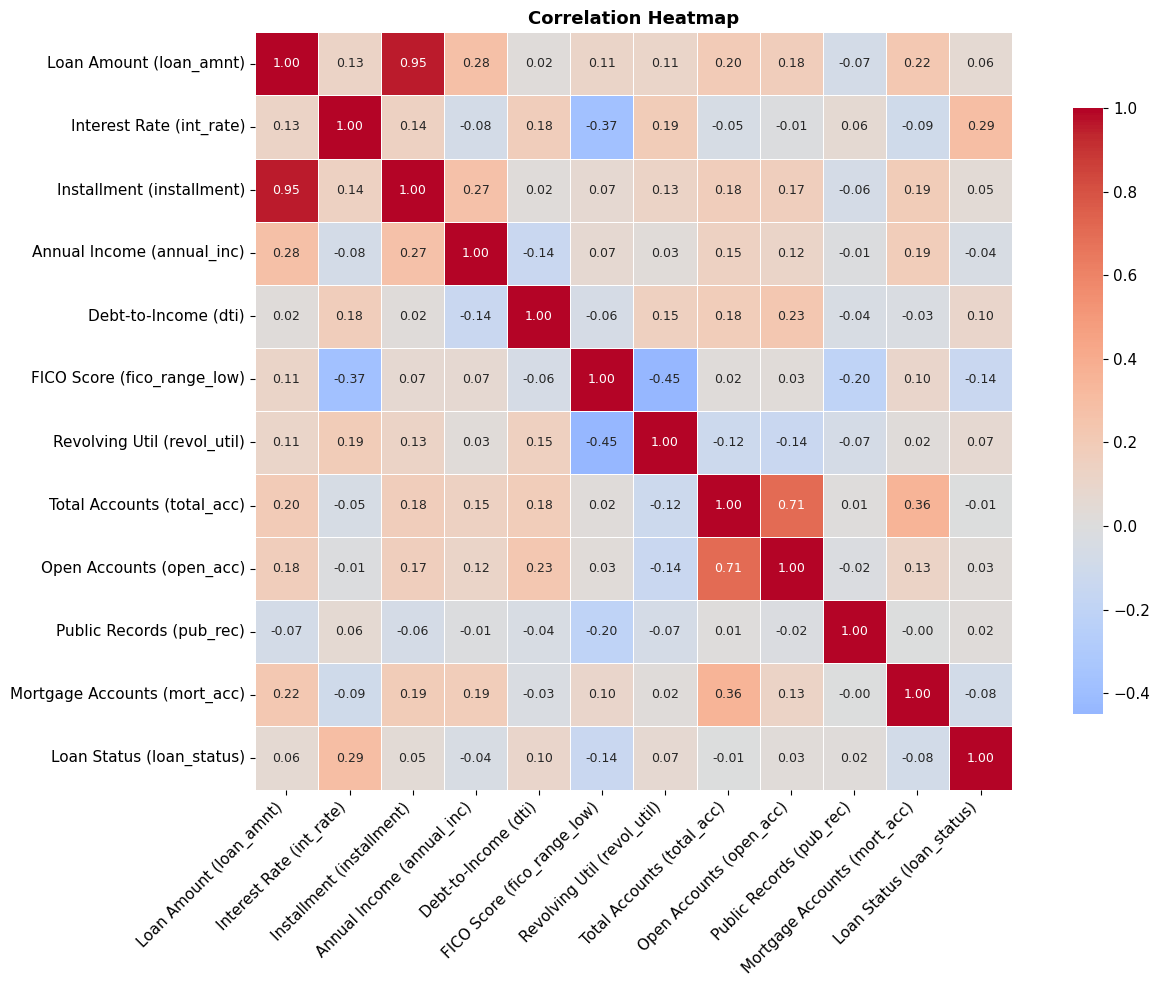

saved → /content/chart9_correlation_heatmap.png


In [ ]:
# key numerical columns for correlation
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'fico_range_low', 'revol_util', 'total_acc',
            'open_acc', 'pub_rec', 'mort_acc', 'loan_status']
# simpler names for the heatmap axes
simpler_names = [
    'Loan Amount (loan_amnt)',
    'Interest Rate (int_rate)',
    'Installment (installment)',
    'Annual Income (annual_inc)',
    'Debt-to-Income (dti)',
    'FICO Score (fico_range_low)',
    'Revolving Util (revol_util)',
    'Total Accounts (total_acc)',
    'Open Accounts (open_acc)',
    'Public Records (pub_rec)',
    'Mortgage Accounts (mort_acc)',
    'Loan Status (loan_status)'
]
# sample to keep it fast
corr_pd = df.select(num_cols).sample(fraction=0.2).toPandas()
corr_pd = corr_pd.apply(pd.to_numeric, errors='coerce')
corr_pd.columns = simpler_names
corr_matrix = corr_pd.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/chart9_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved → /content/chart9_correlation_heatmap.png")

EDA Charts — Save Confirmation

In [ ]:
# check all charts saved
print("=== Ib's Loan Analysis — EDA Charts ===")
files = sorted([f for f in os.listdir('/content/') if f.startswith('chart')])
for f in files:
    size = os.path.getsize(f'/content/{f}') / 1024
    print(f"✅ {f}  ({size:.1f} KB)")
print(f"\n{len(files)}/9 charts saved")

=== Ib's Loan Analysis — EDA Charts ===
✅ chart1_who_defaulted.png  (66.5 KB)
✅ chart2_loan_amounts.png  (72.5 KB)
✅ chart3_grade_analysis.png  (75.4 KB)
✅ chart4_loan_purposes.png  (118.4 KB)
✅ chart5_fico_scores.png  (79.6 KB)
✅ chart6_dti_employment.png  (76.7 KB)
✅ chart7_home_ownership.png  (73.6 KB)
✅ chart8_loan_terms.png  (73.5 KB)
✅ chart9_correlation_heatmap.png  (323.7 KB)

9/9 charts saved


Drop Irrelevant Columns


In [ ]:
# drop irrelevant columns
cols_to_drop = [
    'emp_title',
    'fico_range_high',
    'acc_now_delinq',
    'tax_liens',
    'chargeoff_within_12_mths',
    'num_tl_120dpd_2m'
]
df = df.drop(*cols_to_drop)
df.printSchema()

root
 |-- loan_amnt: double (nullable = true)
 |-- term: integer (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- emp_length: integer (nullable = false)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- loan_status: integer (nullable = true)
 |-- purpose: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- inq_last_6mths: double (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: double (nullable = false)
 |-- total_acc: double (nullable = true)
 |-- collections_12_mths_ex_med: double (nullable = true)
 |-- tot_coll_amt: double (nullable = true)
 |-- tot_cur_bal: double (nullable = true)
 |-- total_r

Outlier Capping

In [ ]:
from pyspark.sql.functions import when, col

# cap extreme values
cleaned_df = df.withColumn('dti', when(col('dti') > 60, 60).otherwise(col('dti'))) \
               .withColumn('revol_util', when(col('revol_util') > 100, 100).otherwise(col('revol_util'))) \
               .withColumn('annual_inc', when(col('annual_inc') > 250000, 250000).otherwise(col('annual_inc')))

# confirm the caps worked
cleaned_df.select('dti', 'revol_util', 'annual_inc').describe().show()

+-------+-----------------+------------------+-----------------+
|summary|              dti|        revol_util|       annual_inc|
+-------+-----------------+------------------+-----------------+
|  count|           611778|            611778|           611778|
|   mean|18.83611533922418| 50.58758765434518|75053.43289443219|
| stddev|8.985898112880419|24.476524747862445| 42864.2961858262|
|    min|             -1.0|               0.0|              0.0|
|    max|             60.0|             100.0|         250000.0|
+-------+-----------------+------------------+-----------------+



Categorical Encoding

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# encode categorical columns

# label encode grade (A=0, B=1, C=2, D=3, E=4, F=5, G=6) - natural order
grade_indexer = StringIndexer(inputCol='grade', outputCol='grade_indexed', stringOrderType='alphabetAsc')

# label encode term (36=0, 60=1)
term_indexer = StringIndexer(inputCol='term', outputCol='term_indexed')

# label encode verification status
verify_indexer = StringIndexer(inputCol='verification_status', outputCol='verification_indexed')

# one-hot encode home ownership
home_indexer = StringIndexer(inputCol='home_ownership', outputCol='home_indexed')
home_encoder = OneHotEncoder(inputCol='home_indexed', outputCol='home_encoded')

# one-hot encode purpose
purpose_indexer = StringIndexer(inputCol='purpose', outputCol='purpose_indexed')
purpose_encoder = OneHotEncoder(inputCol='purpose_indexed', outputCol='purpose_encoded')

# build and run the pipeline
pipeline = Pipeline(stages=[
    grade_indexer,
    term_indexer,
    verify_indexer,
    home_indexer,
    home_encoder,
    purpose_indexer,
    purpose_encoder
])

encoded_df = pipeline.fit(cleaned_df).transform(cleaned_df)

# confirm encoding worked
encoded_df.select('grade', 'grade_indexed', 'term', 'term_indexed',
                  'home_ownership', 'home_encoded',
                  'purpose', 'purpose_encoded').show(5)

+-----+-------------+----+------------+--------------+-------------+------------------+---------------+
|grade|grade_indexed|term|term_indexed|home_ownership| home_encoded|           purpose|purpose_encoded|
+-----+-------------+----+------------+--------------+-------------+------------------+---------------+
|    C|          2.0|  60|         1.0|      MORTGAGE|(4,[0],[1.0])|  home_improvement| (13,[2],[1.0])|
|    E|          4.0|  60|         1.0|          RENT|(4,[1],[1.0])|debt_consolidation| (13,[0],[1.0])|
|    A|          0.0|  36|         0.0|      MORTGAGE|(4,[0],[1.0])|  home_improvement| (13,[2],[1.0])|
|    E|          4.0|  36|         0.0|          RENT|(4,[1],[1.0])|debt_consolidation| (13,[0],[1.0])|
|    B|          1.0|  36|         0.0|      MORTGAGE|(4,[0],[1.0])|  home_improvement| (13,[2],[1.0])|
+-----+-------------+----+------------+--------------+-------------+------------------+---------------+
only showing top 5 rows


Feature Normalisation

In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, MinMaxScaler

# normalise features

# columns for standard scaling
standard_cols = ['dti', 'fico_range_low', 'revol_util', 'installment']

# columns for min-max scaling
minmax_cols = ['loan_amnt', 'annual_inc', 'revol_bal']

# assemble standard scaling columns into a vector
standard_assembler = VectorAssembler(inputCols=standard_cols, outputCol='standard_features')
standard_scaler = StandardScaler(inputCol='standard_features', outputCol='standard_scaled',
                                  withMean=True, withStd=True)

# assemble min-max scaling columns into a vector
minmax_assembler = VectorAssembler(inputCols=minmax_cols, outputCol='minmax_features')
minmax_scaler = MinMaxScaler(inputCol='minmax_features', outputCol='minmax_scaled')

# build and run the pipeline
scaling_pipeline = Pipeline(stages=[
    standard_assembler,
    standard_scaler,
    minmax_assembler,
    minmax_scaler
])

normalised_df = scaling_pipeline.fit(encoded_df).transform(encoded_df)

# confirm scaling worked
normalised_df.select('standard_scaled', 'minmax_scaled').show(5)

+--------------------+--------------------+
|     standard_scaled|       minmax_scaled|
+--------------------+--------------------+
|[-0.2688785593685...|[0.48717948717948...|
|[-0.0095833870073...|[0.35769230769230...|
|[-1.9515150426742...|[0.17948717948717...|
|[3.10195868132776...|[0.19871794871794...|
|[-1.0000241741383...|[0.15897435897435...|
+--------------------+--------------------+
only showing top 5 rows


Class Imbalance Handling

In [ ]:
from pyspark.sql.functions import when, col

# balance the dataset

# calculate class weights based on class distribution
total = normalised_df.count()
default_count = normalised_df.filter(col('loan_status') == 1).count()
no_default_count = normalised_df.filter(col('loan_status') == 0).count()

# weight formula — minority class gets higher weight
default_weight = total / (2 * default_count)
no_default_weight = total / (2 * no_default_count)

print(f"No Default Weight: {no_default_weight:.4f}")
print(f"Default Weight: {default_weight:.4f}")

# add class weight column to the dataframe
balanced_df = normalised_df.withColumn('class_weight',
    when(col('loan_status') == 1, default_weight)
    .otherwise(no_default_weight))

# confirm weights added
balanced_df.groupBy('loan_status', 'class_weight').count().show()

No Default Weight: 0.6338
Default Weight: 2.3678
+-----------+------------------+------+
|loan_status|      class_weight| count|
+-----------+------------------+------+
|          1|2.3678368231605837|129185|
|          0|0.6338446682815541|482593|
+-----------+------------------+------+



Feature Vector Assembly

In [ ]:
from pyspark.ml.feature import VectorAssembler

# build feature vector

# all columns going into the model
feature_cols = [
    'standard_scaled',
    'minmax_scaled',
    'grade_indexed',
    'term_indexed',
    'verification_indexed',
    'home_encoded',
    'purpose_encoded',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'total_acc',
    'mort_acc',
    'delinq_amnt',
    'tot_cur_bal',
    'total_rev_hi_lim',
    'acc_open_past_24mths',
    'num_actv_bc_tl',
    'num_actv_rev_tl',
    'num_bc_sats',
    'pct_tl_nvr_dlq',
    'percent_bc_gt_75'
]

# assemble all features into one vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol='input_features', handleInvalid='skip')
final_df = assembler.transform(balanced_df)

# keep only what the model needs
final_df = final_df.select('input_features', 'loan_status', 'class_weight')

# confirm it worked
print(f"Final dataset rows: {final_df.count()}")
print(f"Final dataset columns: {len(final_df.columns)}")
final_df.show(3)

Final dataset rows: 611778
Final dataset columns: 3
+--------------------+-----------+------------------+
|      input_features|loan_status|      class_weight|
+--------------------+-----------+------------------+
|(42,[0,1,2,3,4,5,...|          0|0.6338446682815541|
|(42,[0,1,2,3,4,5,...|          1|2.3678368231605837|
|(42,[0,1,2,3,4,5,...|          0|0.6338446682815541|
+--------------------+-----------+------------------+
only showing top 3 rows


Model Training, Evaluation & Comparison

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# train/test split — 80/20
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_df.count())
print("Test rows :", test_df.count())

# define all 5 models
models = {
    "Logistic Regression": LogisticRegression(
        labelCol='loan_status',
        featuresCol='input_features',
        weightCol='class_weight',
        maxIter=100
    ),
    "Decision Tree": DecisionTreeClassifier(
        labelCol='loan_status',
        featuresCol='input_features',
        maxDepth=8
    ),
    "Random Forest": RandomForestClassifier(
        labelCol='loan_status',
        featuresCol='input_features',
        weightCol='class_weight',
        numTrees=100,
        maxDepth=10
    ),
    "Gradient Boosted Trees": GBTClassifier(
        labelCol='loan_status',
        featuresCol='input_features',
        weightCol='class_weight',
        maxIter=50,
        maxDepth=5
    ),
    "Linear SVC": LinearSVC(
        labelCol='loan_status',
        featuresCol='input_features',
        weightCol='class_weight',
        maxIter=100
    )
}

# evaluators
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol='loan_status', predictionCol='prediction', metricName='accuracy'
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol='loan_status', predictionCol='prediction', metricName='f1'
)
precision_eval = MulticlassClassificationEvaluator(
    labelCol='loan_status', predictionCol='prediction', metricName='weightedPrecision'
)
recall_eval = MulticlassClassificationEvaluator(
    labelCol='loan_status', predictionCol='prediction', metricName='weightedRecall'
)
auc_eval = BinaryClassificationEvaluator(
    labelCol='loan_status', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

# train and evaluate all models
results = []
predictions_dict = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    fitted_model = model.fit(train_df)
    preds = fitted_model.transform(test_df)
    predictions_dict[model_name] = preds
    accuracy = accuracy_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    precision = precision_eval.evaluate(preds)
    recall = recall_eval.evaluate(preds)
    # linear svc doesnt support auc properly so handle it
    try:
        auc = auc_eval.evaluate(preds)
    except:
        auc = 0.0
    results.append((model_name, accuracy, f1, precision, recall, auc))
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"AUC      : {auc:.4f}")
    # confusion matrix for each model
    print(f"\nConfusion Matrix — {model_name}")
    preds.groupBy('loan_status', 'prediction').count().orderBy('loan_status', 'prediction').show()

# final model comparison ranked by AUC
model_results = spark.createDataFrame(
    results,
    ["Model", "Accuracy", "F1", "Precision", "Recall", "AUC"]
)
print("\nFINAL MODEL COMPARISON — Ranked by AUC")
model_results.orderBy(col("AUC").desc()).show(truncate=False)

# best model based on AUC
best_row = model_results.orderBy(col("AUC").desc()).first()
best_model_name = best_row["Model"]
print(f"\nBest model: {best_model_name}")
print(best_row)

Train rows: 489416
Test rows : 122362

Training: Logistic Regression
Accuracy : 0.6708
F1 Score : 0.6990
Precision: 0.7663
Recall   : 0.6708
AUC      : 0.7244

Confusion Matrix — Logistic Regression
+-----------+----------+-----+
|loan_status|prediction|count|
+-----------+----------+-----+
|          0|       0.0|65414|
|          0|       1.0|31175|
|          1|       0.0| 9102|
|          1|       1.0|16671|
+-----------+----------+-----+


Training: Decision Tree
Accuracy : 0.7920
F1 Score : 0.7257
Precision: 0.7458
Recall   : 0.7920
AUC      : 0.4729

Confusion Matrix — Decision Tree
+-----------+----------+-----+
|loan_status|prediction|count|
+-----------+----------+-----+
|          0|       0.0|94826|
|          0|       1.0| 1763|
|          1|       0.0|23685|
|          1|       1.0| 2088|
+-----------+----------+-----+


Training: Random Forest
Accuracy : 0.6655
F1 Score : 0.6946
Precision: 0.7672
Recall   : 0.6655
AUC      : 0.7244

Confusion Matrix — Random Forest
+----

Hyperparameter Tuning & Performance Optimisation

In [ ]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# repartition and cache train/test data
print("Setting up data for faster processing...")
train_df = train_df.repartition(8).cache()
test_df = test_df.repartition(8).cache()

# baseline GBT model
baseline_gbt = GBTClassifier(
    labelCol='loan_status',
    featuresCol='input_features',
    weightCol='class_weight',
    maxIter=50,
    maxDepth=5,
    seed=42
)

# sample 10% of training data for tuning
tuning_train_df = train_df.sample(False, 0.10, seed=42)
print("Tuning dataset size:", tuning_train_df.count())

# parameter grid to test
param_grid = (
    ParamGridBuilder()
    .addGrid(baseline_gbt.maxDepth, [5, 7, 9])
    .addGrid(baseline_gbt.maxIter, [30, 50, 70])
    .addGrid(baseline_gbt.stepSize, [0.05, 0.1, 0.2])
    .build()
)

# auc evaluator
auc_eval = BinaryClassificationEvaluator(
    labelCol='loan_status',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)

# train validation split 80/20
tvs = TrainValidationSplit(
    estimator=baseline_gbt,
    estimatorParamMaps=param_grid,
    evaluator=auc_eval,
    trainRatio=0.8,
    parallelism=1,
    seed=42
)

# fit the tuned model
print("\nRunning hyperparameter tuning...")
tvs_model = tvs.fit(tuning_train_df)
best_gbt = tvs_model.bestModel

print("\n====================")
print(" Optimal GBT Settings")
print("====================")
print("maxDepth =", best_gbt.getMaxDepth())
print("maxIter  =", best_gbt.getMaxIter())
print("stepSize =", best_gbt.getStepSize())
print("====================")

# evaluate tuned model on full test set
tuned_preds = best_gbt.transform(test_df)

acc_eval = MulticlassClassificationEvaluator(labelCol='loan_status', predictionCol='prediction', metricName='accuracy')
f1_eval = MulticlassClassificationEvaluator(labelCol='loan_status', predictionCol='prediction', metricName='f1')
precision_eval = MulticlassClassificationEvaluator(labelCol='loan_status', predictionCol='prediction', metricName='weightedPrecision')
recall_eval = MulticlassClassificationEvaluator(labelCol='loan_status', predictionCol='prediction', metricName='weightedRecall')

tuned_accuracy = acc_eval.evaluate(tuned_preds)
tuned_f1 = f1_eval.evaluate(tuned_preds)
tuned_precision = precision_eval.evaluate(tuned_preds)
tuned_recall = recall_eval.evaluate(tuned_preds)
tuned_auc = auc_eval.evaluate(tuned_preds)

print("\n======================================")
print("     Tuned Gradient Boosted Trees")
print("======================================")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"AUC      : {tuned_auc:.4f}")

# confusion matrix
print("\nConfusion Matrix — Tuned GBT")
tuned_preds.groupBy('loan_status', 'prediction') \
           .count() \
           .orderBy('loan_status', 'prediction') \
           .show()

Setting up data for faster processing...
Tuning dataset size: 48996

Running hyperparameter tuning...

 Optimal GBT Settings
maxDepth = 5
maxIter  = 70
stepSize = 0.05

     Tuned Gradient Boosted Trees
Accuracy : 0.6592
F1 Score : 0.6892
Precision: 0.7660
Recall   : 0.6592
AUC      : 0.7211

Confusion Matrix — Tuned GBT
+-----------+----------+-----+
|loan_status|prediction|count|
+-----------+----------+-----+
|          0|       0.0|63606|
|          0|       1.0|32983|
|          1|       0.0| 8721|
|          1|       1.0|17052|
+-----------+----------+-----+

